In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from avito_retrieval.data.loader import (
    load_train, load_benchmark_queries, load_benchmark_items,
    build_item_text, build_query_text,
)

train = load_train()
bench_queries = load_benchmark_queries()
bench_items = load_benchmark_items()

print("train:", train.shape)
print("bench_queries:", bench_queries.shape)
print("bench_items:", bench_items.shape)

train.head(3)

train: (497673, 19)
bench_queries: (2452, 6)
bench_items: (189212, 14)


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114


In [2]:
cols_to_check = [
    "search_infm_params_text", "item_description_raw",
    "item_infm_params_text", "item_rating", "item_price",
]
for col in cols_to_check:
    if col in train.columns:
        empty_share = train[col].isna().mean()
        print(f"{col}: {empty_share:.2%} пустых")

search_infm_params_text: 0.00% пустых
item_description_raw: 0.00% пустых
item_infm_params_text: 0.00% пустых
item_rating: 5.67% пустых
item_price: 0.00% пустых


In [3]:
from transformers import AutoTokenizer
from avito_retrieval import config

tokenizer = AutoTokenizer.from_pretrained(config.BIENCODER_MODEL_NAME)


def token_lengths(texts: pd.Series, batch_size: int = 512) -> np.ndarray:
    """Считает длину в токенах батчами, без padding (реальная длина текста)."""
    lengths = []
    texts = texts.tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=False, padding=False)
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return np.array(lengths)


query_texts = build_query_text(train)
item_texts = build_item_text(train)

query_lens = token_lengths(query_texts)
item_lens = token_lengths(item_texts)


def print_percentiles(name: str, arr: np.ndarray):
    percentiles = [50, 75, 90, 95, 99, 100]
    values = np.percentile(arr, percentiles)
    print(f"\n{name}:")
    for p, v in zip(percentiles, values):
        print(f"  p{p}: {v:.0f} токенов")


print_percentiles("Длина запроса (query + params)", query_lens)
print_percentiles("Длина объявления (title + params + description)", item_lens)

/Users/lex/PycharmProjects/Basic-Search-Engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (775 > 512). Running this sequence through the model will result in indexing errors



Длина запроса (query + params):
  p50: 15 токенов
  p75: 21 токенов
  p90: 27 токенов
  p95: 33 токенов
  p99: 38 токенов
  p100: 297 токенов

Длина объявления (title + params + description):
  p50: 557 токенов
  p75: 869 токенов
  p90: 1289 токенов
  p95: 1645 токенов
  p99: 2365 токенов
  p100: 5972 токенов


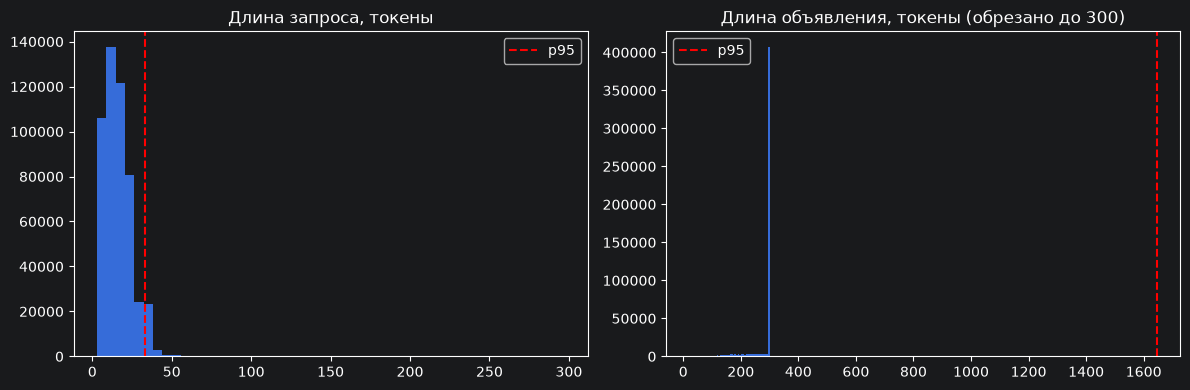

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(query_lens, bins=50)
axes[0].set_title("Длина запроса, токены")
axes[0].axvline(np.percentile(query_lens, 95), color="red", linestyle="--", label="p95")
axes[0].legend()

# Обрезаем хвост для читаемости графика объявлений
axes[1].hist(np.clip(item_lens, 0, 300), bins=50)
axes[1].set_title("Длина объявления, токены (обрезано до 300)")
axes[1].axvline(np.percentile(item_lens, 95), color="red", linestyle="--", label="p95")
axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# Если у одного текста запроса почти всегда одна категория объявления —
# это сигнал в пользу фильтрации кандидатов по категории до текстового поиска
query_to_category = (
    train.groupby("search_query")["item_category_id"]
    .agg(lambda x: x.value_counts(normalize=True).iloc[0])
)
print("Доля случаев, когда топ-категория покрывает >=80% выборов по запросу:")
print((query_to_category >= 0.8).mean())


# Средняя энтропия категорий на запрос (ниже = запрос сильнее определяет категорию)
def normalized_entropy(series):
    counts = series.value_counts(normalize=True)
    return -(counts * np.log(counts + 1e-12)).sum()


entropy_per_query = train.groupby("search_query")["item_category_id"].apply(normalized_entropy)
print("\nМедианная энтропия категории на запрос:", entropy_per_query.median())

Доля случаев, когда топ-категория покрывает >=80% выборов по запросу:
0.9999731648083297

Медианная энтропия категории на запрос: -1.000088900581841e-12


In [6]:
title_counts = bench_items["item_title_raw"].value_counts()
print("Топ-10 самых частых заголовков объявлений:")
print(title_counts.head(10))
print(f"\nДоля объявлений с неуникальным title: {(title_counts[title_counts > 1].sum() / len(bench_items)):.2%}")

Топ-10 самых частых заголовков объявлений:
item_title_raw
Наращивание ресниц                869
Репетитор по английскому языку    574
Маникюр                           504
Массаж                            503
Грузоперевозки                    482
Репетитор по математике           426
Фотограф                          343
Вывоз мусора                      342
Натяжные потолки                  248
Наращивание волос                 216
Name: count, dtype: int64

Доля объявлений с неуникальным title: 44.48%
